In [ ]:
# =============================================================================
# BLOK 0-A — ORTAM KURULUMU, DRIVE BAĞLANTISI, MODEL MİMARİSİ
# (Eğitim notebook'u çalıştırmadan bağımsız çalışır)
# =============================================================================

import os, gc, math, time, joblib
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import mixed_precision
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, LSTM, Dense, Dropout, LayerNormalization,
    MultiHeadAttention, Add, TimeDistributed, Conv1D,
    Bidirectional, Lambda
)
from google.colab import drive

print("=" * 65)
print("   BLOK 0-A: ORTAM KURULUMU BAŞLATILIYOR")
print("=" * 65)

# ── Drive ──────────────────────────────────────────────────────────────────
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')
print("✅ Google Drive bağlandı")

# ── GPU ────────────────────────────────────────────────────────────────────
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    det = tf.config.experimental.get_device_details(gpus[0])
    gpu_name = det.get('device_name', 'Bilinmiyor')
    print(f"✅ GPU: {gpu_name}")
    if 'H100' in gpu_name or 'A100' in gpu_name:
        mixed_precision.set_global_policy('mixed_bfloat16')
        tf.config.optimizer.set_jit(True)
        print("✅ Mixed Precision: bfloat16 | XLA: AKTİF")
    else:
        mixed_precision.set_global_policy('float32')
        print("✅ Precision: float32 (T4/V100 uyumlu)")
else:
    print("⚠️  GPU bulunamadı — CPU ile devam ediliyor")

# ── Global Sabitler ────────────────────────────────────────────────────────
ROOT_PATH      = '/content/drive/MyDrive/wifi_mqtt'   # ← Ham veri klasörün
SAVE_DIR       = '/content/drive/MyDrive/mha_federe_outputs'
RESULTS_DIR    = f'{SAVE_DIR}/test_sonuclari'
MODEL_PATH     = f'{SAVE_DIR}/federe_mha_lstm_best.keras'

os.makedirs(RESULTS_DIR, exist_ok=True)

TIME_STEPS     = 20
PCA_VARIANCE   = 0.95
SEED           = 42
TEST_SIZE      = 0.20
BATCH_SIZE     = 512    # H100 için; T4'te 512'ye düşür
LEARNING_RATE  = 0.001

np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── NaN-Safe Loss ──────────────────────────────────────────────────────────
def combined_reconstruction_loss(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    mae = tf.reduce_mean(tf.abs(y_true - y_pred))
    mse = tf.reduce_mean(tf.square(y_true - y_pred))
    return 0.6 * mae + 0.4 * mse

# ── Transformer Bloğu ──────────────────────────────────────────────────────
def transformer_encoder_block(x, embed_dim, num_heads, ff_dim,
                               dropout_rate, name_prefix=""):
    attn_input  = LayerNormalization(epsilon=1e-5, name=f"{name_prefix}_ln1")(x)
    attn_output = MultiHeadAttention(
        num_heads=num_heads, key_dim=embed_dim // num_heads,
        dropout=dropout_rate, name=f"{name_prefix}_mha"
    )(attn_input, attn_input)
    x = Add(name=f"{name_prefix}_add1")([x, attn_output])
    ff_input  = LayerNormalization(epsilon=1e-5, name=f"{name_prefix}_ln2")(x)
    ff_output = Dense(ff_dim, activation='relu', name=f"{name_prefix}_ff1")(ff_input)
    ff_output = Dropout(dropout_rate, name=f"{name_prefix}_drop")(ff_output)
    ff_output = Dense(embed_dim, name=f"{name_prefix}_ff2")(ff_output)
    x = Add(name=f"{name_prefix}_add2")([x, ff_output])
    return x

# ── Model Mimarisi ─────────────────────────────────────────────────────────
def build_model(time_steps, pca_components):
    inputs = Input(shape=(time_steps, pca_components), dtype='float32', name='input')

    # ENCODER
    x = Conv1D(64, kernel_size=3, padding='same', activation='relu', name='conv_local')(inputs)
    x = Bidirectional(
        LSTM(128, return_sequences=True, activation='tanh',
             kernel_initializer='glorot_uniform', recurrent_initializer='orthogonal'),
        name='bilstm_encoder'
    )(x)
    x = Dropout(0.15, name='drop_enc_1')(x)
    x = transformer_encoder_block(x, embed_dim=256, num_heads=4, ff_dim=512,
                                   dropout_rate=0.1, name_prefix="enc_transformer")
    encoder_out = LSTM(64, return_sequences=True, activation='tanh',
                       kernel_initializer='glorot_uniform',
                       recurrent_initializer='orthogonal', name='bottleneck')(x)
    encoder_out = LayerNormalization(epsilon=1e-5, name='bottleneck_ln')(encoder_out)
    x = transformer_encoder_block(encoder_out, embed_dim=64, num_heads=4, ff_dim=128,
                                   dropout_rate=0.1, name_prefix="bottleneck_transformer")

    # DECODER
    x = LSTM(128, return_sequences=True, activation='tanh',
             kernel_initializer='glorot_uniform',
             recurrent_initializer='orthogonal', name='lstm_dec_1')(x)
    x = Dropout(0.15, name='drop_dec_1')(x)
    x = transformer_encoder_block(x, embed_dim=128, num_heads=4, ff_dim=256,
                                   dropout_rate=0.1, name_prefix="dec_transformer")
    x = LSTM(256, return_sequences=True, activation='tanh',
             kernel_initializer='glorot_uniform',
             recurrent_initializer='orthogonal', name='lstm_dec_2')(x)
    x = Dropout(0.1, name='drop_dec_2')(x)
    x = TimeDistributed(Dense(pca_components), name='output_dense')(x)
    outputs = Lambda(lambda t: tf.cast(t, tf.float32), name='output_cast')(x)

    model = Model(inputs=inputs, outputs=outputs, name='Federe_MHA_LSTM_Autoencoder')
    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=LEARNING_RATE, clipvalue=0.5, epsilon=1e-7
        ),
        loss=combined_reconstruction_loss
    )
    return model

print("\n✅ build_model() ve combined_reconstruction_loss() tanımlandı")
print("\n" + "=" * 65)
print("   BLOK 0-A TAMAMLANDI — BLOK 0-B'YE GEÇİN")
print("=" * 65)

   BLOK 0-A: ORTAM KURULUMU BAŞLATILIYOR
✅ Google Drive bağlandı
✅ GPU: Tesla T4
✅ Precision: float32 (T4/V100 uyumlu)

✅ build_model() ve combined_reconstruction_loss() tanımlandı

   BLOK 0-A TAMAMLANDI — BLOK 0-B'YE GEÇİN


In [ ]:
# =============================================================================
# BLOK 0-B — SCALER/PCA/MODEL YÜKLEME + CLIENT DATASETS + X_normal/X_attack
# (Eğitim tamamen atlanır — Drive'dan direkt yüklenir)
# =============================================================================

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

print("=" * 65)
print("   BLOK 0-B: DRIVE'DAN YÜKLEME + VERİ HAZIRLAMA")
print("=" * 65)

# ── 1. Scaler ve PCA ───────────────────────────────────────────────────────
# Önce Drive'da kayıtlı pkl var mı dene, yoksa normal veriden yeniden fit et
scaler_path = f'{SAVE_DIR}/federe_mha_scaler.pkl'
pca_path    = f'{SAVE_DIR}/federe_mha_pca.pkl'

if os.path.exists(scaler_path) and os.path.exists(pca_path):
    scaler = joblib.load(scaler_path)
    pca    = joblib.load(pca_path)
    PCA_COMPONENTS = pca.n_components_
    FEATURE_COLUMNS = list(scaler.feature_names_in_)
    print(f"✅ Scaler yüklendi — {len(FEATURE_COLUMNS)} özellik")
    print(f"✅ PCA yüklendi — {PCA_COMPONENTS} bileşen")
else:
    print("⚠️  pkl bulunamadı — normal veriden yeniden fit ediliyor...")
    print("   (Bu işlem 2-5 dakika sürebilir)")

    all_benign_files = []
    for root, dirs, files in os.walk(ROOT_PATH):
        for file in files:
            if file.endswith(".csv") and 'profiling' in root.lower():
                all_benign_files.append(os.path.join(root, file))

    if not all_benign_files:
        raise ValueError(
            f"❌ Profiling dosyası bulunamadı!\n"
            f"   ROOT_PATH={ROOT_PATH} altında 'profiling' klasörü olmalı."
        )
    print(f"   -> {len(all_benign_files)} profiling dosyası bulundu")

    dfs = []
    for f in all_benign_files:
        try:
            df = pd.read_csv(f)
            df = df.select_dtypes(include=[np.number]).astype('float32')
            df.replace([np.inf, -np.inf], np.nan, inplace=True)
            df.dropna(inplace=True)
            dfs.append(df)
        except:
            pass

    df_full = pd.concat(dfs, ignore_index=True)
    del dfs; gc.collect()

    # Sıfır varyanslı kolonları sil
    varyanslar = df_full.var()
    sifir_var  = varyanslar[varyanslar == 0].index.tolist()
    df_full.drop(columns=sifir_var, inplace=True)
    FEATURE_COLUMNS = df_full.columns.tolist()

    scaler = StandardScaler()
    scaled_full = scaler.fit_transform(df_full)
    joblib.dump(scaler, scaler_path)

    pca_full = PCA(random_state=SEED)
    pca_full.fit(scaled_full)
    cum_var = np.cumsum(pca_full.explained_variance_ratio_)
    PCA_COMPONENTS = int(np.argmax(cum_var >= PCA_VARIANCE) + 1)

    pca = PCA(n_components=PCA_COMPONENTS, random_state=SEED)
    pca.fit(scaled_full)
    joblib.dump(pca, pca_path)

    del scaled_full, pca_full, df_full; gc.collect()
    print(f"✅ Scaler & PCA fit edildi ve kaydedildi")
    print(f"   -> PCA_COMPONENTS: {PCA_COMPONENTS}")

print(f"\n   PCA_COMPONENTS : {PCA_COMPONENTS}")
print(f"   FEATURE_COLUMNS: {len(FEATURE_COLUMNS)} özellik")

# ── 2. Normal Veriden Client Datasets ─────────────────────────────────────
print("\n📂 Normal (profiling) dosyaları taranıyor...")

all_benign_files = []
for root, dirs, files in os.walk(ROOT_PATH):
    for file in files:
        if file.endswith(".csv") and 'profiling' in root.lower():
            all_benign_files.append(os.path.join(root, file))

print(f"   -> {len(all_benign_files)} dosya bulundu")

wifi_files, mqtt_files = [], []
for f in all_benign_files:
    fname = os.path.basename(f).lower()
    if 'mqtt' in fname:
        mqtt_files.append(f)
    else:
        wifi_files.append(f)

if len(mqtt_files) < 2:
    mid = len(all_benign_files) // 2
    wifi_files = all_benign_files[:mid]
    mqtt_files = all_benign_files[mid:]

def load_client_df(file_list):
    dfs = []
    for f in file_list:
        try:
            df = pd.read_csv(f)
            df = df.select_dtypes(include=[np.number]).astype('float32')
            df.replace([np.inf, -np.inf], np.nan, inplace=True)
            df.dropna(inplace=True)
            for col in set(FEATURE_COLUMNS) - set(df.columns):
                df[col] = 0.0
            df = df[FEATURE_COLUMNS]
            dfs.append(df)
        except:
            pass
    return pd.concat(dfs, ignore_index=True)

df_wifi_all = load_client_df(wifi_files)
df_mqtt_all = load_client_df(mqtt_files)

# Non-IID bölünme — eğitim notebook'uyla aynı
w_cut1 = int(len(df_wifi_all) * 0.70)
w_cut2 = w_cut1 + int(len(df_wifi_all) * 0.20)
m_cut1 = int(len(df_mqtt_all) * 0.70)
m_cut2 = m_cut1 + int(len(df_mqtt_all) * 0.20)

client_dfs = [
    (df_wifi_all.iloc[:w_cut1],              "Hastane"),
    (df_wifi_all.iloc[w_cut1:w_cut2],        "Klinik"),
    (df_mqtt_all.iloc[:m_cut1],              "IoMT_Ana"),
    (df_mqtt_all.iloc[m_cut1:m_cut2],        "Sensör"),
    (pd.concat([df_wifi_all.iloc[w_cut2:],
                df_mqtt_all.iloc[m_cut2:]], ignore_index=True), "Ambulans"),
]
del df_wifi_all, df_mqtt_all; gc.collect()

def create_sequences_fast(data, time_steps):
    n = data.shape[0] - time_steps
    shape   = (n, time_steps, data.shape[1])
    strides = (data.strides[0], data.strides[0], data.strides[1])
    return np.array(np.lib.stride_tricks.as_strided(
        data, shape=shape, strides=strides), dtype=np.float32)

AUTOTUNE = tf.data.AUTOTUNE

def make_client_dataset(df, name):
    scaled = scaler.transform(df).astype(np.float32)
    pca_t  = pca.transform(scaled).astype(np.float32)
    seqs   = create_sequences_fast(pca_t, TIME_STEPS)
    split  = int(len(seqs) * (1 - TEST_SIZE))
    X_tr, X_val = seqs[:split], seqs[split:]

    train_ds = (
        tf.data.Dataset.from_tensor_slices((X_tr, X_tr))
        .cache().shuffle(10000, seed=SEED)
        .batch(BATCH_SIZE, drop_remainder=True).prefetch(AUTOTUNE)
    )
    val_ds = (
        tf.data.Dataset.from_tensor_slices((X_val, X_val))
        .cache().batch(BATCH_SIZE, drop_remainder=False).prefetch(AUTOTUNE)
    )
    print(f"   -> [{name:<10}] train={len(X_tr):>7,} | val={len(X_val):>6,}")
    return {"name": name, "train": train_ds, "val": val_ds,
            "n_train": len(X_tr), "n_val": len(X_val)}

print("\n⚡ Client pipeline'ları oluşturuluyor...")
CLIENT_DATASETS_H100 = []
for df, name in client_dfs:
    CLIENT_DATASETS_H100.append(make_client_dataset(df, name))
del client_dfs; gc.collect()

# ── 3. Baseline Modeli Yükle + INITIAL_WEIGHTS ─────────────────────────────
print(f"\n📥 Model yükleniyor: {MODEL_PATH}")
tf.keras.backend.clear_session(); gc.collect()

baseline_model = build_model(TIME_STEPS, PCA_COMPONENTS)
baseline_model.load_weights(MODEL_PATH)
print(f"✅ Baseline model yüklendi — {baseline_model.count_params():,} parametre")

INITIAL_WEIGHTS = [w.copy() for w in baseline_model.get_weights()]
joblib.dump(INITIAL_WEIGHTS, f'{RESULTS_DIR}/initial_weights.pkl')
print(f"✅ INITIAL_WEIGHTS saklandı ve Drive'a kaydedildi")

# ── 4. X_normal Hazırla ────────────────────────────────────────────────────
print("\n📊 X_normal hazırlanıyor (val setlerinden)...")
normal_parts = []
for cd in CLIENT_DATASETS_H100:
    for bx, _ in cd["val"]:
        normal_parts.append(bx.numpy())
X_normal_full = np.concatenate(normal_parts, axis=0)
del normal_parts; gc.collect()

MAX_EVAL = 30_000
if len(X_normal_full) > MAX_EVAL:
    idx = np.random.choice(len(X_normal_full), MAX_EVAL, replace=False)
    X_normal = X_normal_full[idx]
else:
    X_normal = X_normal_full
del X_normal_full; gc.collect()
print(f"   -> X_normal shape: {X_normal.shape}")

# ── 5. X_attack Hazırla ────────────────────────────────────────────────────
print("\n📂 Attack dosyaları taranıyor...")
attack_files = []
for root, dirs, files in os.walk(ROOT_PATH):
    for file in files:
        if file.endswith(".csv") and any(
            kw in root.lower() for kw in ['attack','attacks','saldiri','anomaly','malicious','intrusion']
        ):
            attack_files.append(os.path.join(root, file))

print(f"   -> Bulunan attack dosyası: {len(attack_files)}")

if attack_files:
    atk_dfs = []
    for f in attack_files:
        try:
            df = pd.read_csv(f)
            df = df.select_dtypes(include=[np.number]).astype('float32')
            df.replace([np.inf, -np.inf], np.nan, inplace=True)
            df.dropna(inplace=True)
            for col in set(FEATURE_COLUMNS) - set(df.columns):
                df[col] = 0.0
            df = df[FEATURE_COLUMNS]
            atk_dfs.append(df)
        except Exception as e:
            print(f"   ⚠️ Atlandı: {os.path.basename(f)}")

    df_attack = pd.concat(atk_dfs, ignore_index=True)
    del atk_dfs; gc.collect()

    scaled_atk = scaler.transform(df_attack).astype(np.float32)
    pca_atk    = pca.transform(scaled_atk).astype(np.float32)
    X_attack_full = create_sequences_fast(pca_atk, TIME_STEPS)
    del df_attack, scaled_atk, pca_atk; gc.collect()

    if len(X_attack_full) > MAX_EVAL:
        idx = np.random.choice(len(X_attack_full), MAX_EVAL, replace=False)
        X_attack = X_attack_full[idx]
    else:
        X_attack = X_attack_full
    del X_attack_full; gc.collect()
    ATTACK_DATA_AVAILABLE = True
    print(f"✅ X_attack shape: {X_attack.shape}  (gerçek saldırı verisi)")
else:
    print("⚠️  Attack dosyası bulunamadı → sentetik saldırı üretiliyor")
    np.random.seed(42)
    X_attack = X_normal + 3.0 * np.random.randn(*X_normal.shape).astype(np.float32)
    ATTACK_DATA_AVAILABLE = False
    print(f"   -> X_attack shape: {X_attack.shape}  (sentetik — gürültü x3)")

print(f"\n📋 ÖZET:")
print(f"   PCA_COMPONENTS  : {PCA_COMPONENTS}")
print(f"   CLIENT sayısı   : {len(CLIENT_DATASETS_H100)}")
print(f"   X_normal shape  : {X_normal.shape}")
print(f"   X_attack shape  : {X_attack.shape}")
print(f"   MODEL_PATH      : {MODEL_PATH}")

print("\n" + "=" * 65)
print("   BLOK 0-B TAMAMLANDI")
print("   ─────────────────────────────────────────")
print("   Artık mevcut BLOK 1, 2, 3... sırasıyla çalıştırılabilir")
print("=" * 65)

   BLOK 0-B: DRIVE'DAN YÜKLEME + VERİ HAZIRLAMA
✅ Scaler yüklendi — 40 özellik
✅ PCA yüklendi — 20 bileşen

   PCA_COMPONENTS : 20
   FEATURE_COLUMNS: 40 özellik

📂 Normal (profiling) dosyaları taranıyor...
   -> 42 dosya bulundu

⚡ Client pipeline'ları oluşturuluyor...
   -> [Hastane   ] train= 73,418 | val=18,355
   -> [Klinik    ] train= 20,964 | val= 5,242
   -> [IoMT_Ana  ] train=144,924 | val=36,232
   -> [Sensör    ] train= 41,395 | val=10,349
   -> [Ambulans  ] train= 31,181 | val= 7,796

📥 Model yükleniyor: /content/drive/MyDrive/mha_federe_outputs/federe_mha_lstm_best.keras
✅ Baseline model yüklendi — 1,475,092 parametre
✅ INITIAL_WEIGHTS saklandı ve Drive'a kaydedildi

📊 X_normal hazırlanıyor (val setlerinden)...
   -> X_normal shape: (30000, 20, 20)

📂 Attack dosyaları taranıyor...
   -> Bulunan attack dosyası: 72
✅ X_attack shape: (30000, 20, 20)  (gerçek saldırı verisi)

📋 ÖZET:
   PCA_COMPONENTS  : 20
   CLIENT sayısı   : 5
   X_normal shape  : (30000, 20, 20)
   X_attac

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Blok 0-B çalıştıktan hemen sonra şunları yazdır:
print(f"ATTACK_DATA_AVAILABLE : {ATTACK_DATA_AVAILABLE}")
print(f"X_attack kaynağı      : {'GERÇEK' if ATTACK_DATA_AVAILABLE else 'SENTETİK ⚠️'}")
print(f"PCA_COMPONENTS        : {PCA_COMPONENTS}")

# Threshold karşılaştırması
saved_thresh = joblib.load(f'{SAVE_DIR}/federe_mha_threshold.pkl')
print(f"Kayıtlı threshold     : {saved_thresh:.5f}")

ATTACK_DATA_AVAILABLE : True
X_attack kaynağı      : GERÇEK
PCA_COMPONENTS        : 20
Kayıtlı threshold     : 0.02156


In [ ]:
# BLOK 0-B çalıştıktan hemen sonra
print(f"ATTACK_DATA_AVAILABLE : {ATTACK_DATA_AVAILABLE}")
print(f"X_attack kaynağı      : {'GERÇEK' if ATTACK_DATA_AVAILABLE else 'SENTETİK ⚠️'}")
print(f"MODEL_PATH            : {MODEL_PATH}")
print(f"MODEL_PATH var mı     : {os.path.exists(MODEL_PATH)}")

# Threshold karşılaştırması
saved_thresh = joblib.load(f'{SAVE_DIR}/federe_mha_threshold.pkl')
print(f"\nKayıtlı threshold     : {saved_thresh:.5f}")
print(f"Baseline threshold    : {metrics_baseline['threshold']:.5f}")

ATTACK_DATA_AVAILABLE : True
X_attack kaynağı      : GERÇEK
MODEL_PATH            : /content/drive/MyDrive/mha_federe_outputs/federe_mha_lstm_best.keras
MODEL_PATH var mı     : True

Kayıtlı threshold     : 0.02156
Baseline threshold    : 0.05154


In [ ]:
# ROOT_PATH altındaki TÜM klasör isimlerini listele
for root, dirs, files in os.walk(ROOT_PATH):
    depth = root.replace(ROOT_PATH, '').count(os.sep)
    if depth <= 2:
        csv_count = len([f for f in files if f.endswith('.csv')])
        if csv_count > 0:
            print(f"{'  '*depth}{os.path.basename(root)}/ → {csv_count} CSV")

    CSV/ → 42 CSV
  saved_models/ → 1 CSV
    WalkForward_CV_20260223_2217/ → 1 CSV


In [ ]:
# ESKİ — Drive'dan yükleme (eğitim datasına göre hesaplanmış)
FIXED_THRESHOLD = joblib.load(f'{SAVE_DIR}/federe_mha_threshold.pkl')

# YENİ — Baseline modeli üzerinden bu notebookun verisine göre hesapla
err_n_for_thresh = reconstruction_error(baseline_model, X_normal)
err_a_for_thresh = reconstruction_error(baseline_model, X_attack)

all_scores = np.concatenate([err_n_for_thresh, err_a_for_thresh])
all_labels = np.concatenate([np.zeros(len(err_n_for_thresh)),
                              np.ones(len(err_a_for_thresh))])

from sklearn.metrics import f1_score as sk_f1
t_min = np.percentile(err_n_for_thresh, 90)
t_max = np.percentile(err_a_for_thresh, 99)
thresholds = np.linspace(t_min, t_max, 500)

best_f1, FIXED_THRESHOLD = 0.0, t_min
for t in thresholds:
    y_pred_t = (all_scores > t).astype(int)
    f1 = sk_f1(all_labels, y_pred_t, zero_division=0)
    if f1 > best_f1:
        best_f1 = f1
        FIXED_THRESHOLD = t

print(f"Yeni FIXED_THRESHOLD  : {FIXED_THRESHOLD:.5f}")
print(f"Beklenen F1           : {best_f1:.4f}")
print(f"Normal FP oranı       : %{(err_n_for_thresh > FIXED_THRESHOLD).mean()*100:.1f}")
print(f"Attack TP oranı       : %{(err_a_for_thresh > FIXED_THRESHOLD).mean()*100:.1f}")

Yeni FIXED_THRESHOLD  : 0.16514
Beklenen F1           : 0.9865
Normal FP oranı       : %0.1
Attack TP oranı       : %97.4


In [ ]:
# =============================================================================
# BLOK 1 — YAPILANDIRMA
# =============================================================================

ALPHA_POISON               = 2.0
COMPROMISED_CLIENT_INDICES = [1, 2]
EVAL_ROUNDS   = 10
EVAL_EPOCHS   = 3
PATIENCE      = 5
TRIM_RATIO    = 0.2
NOISE_SCALE   = 1e-4
PERCENTILE_THRESHOLD = 95

SAVE_DIR    = '/content/drive/MyDrive/mha_federe_outputs'
RESULTS_DIR = f'{SAVE_DIR}/senaryo_alpha4_clients12'
os.makedirs(RESULTS_DIR, exist_ok=True)

# ── THRESHOLD — PR optimize (arkadaşınla aynı) ─────────────────────────────
FIXED_THRESHOLD = joblib.load(f'{SAVE_DIR}/federe_mha_threshold_pr.pkl')
print(f"[OK] FIXED_THRESHOLD (PR): {FIXED_THRESHOLD:.5f}")

# Hızlı kontrol
err_n_check = reconstruction_error(baseline_model, X_normal)
err_a_check = reconstruction_error(baseline_model, X_attack)
print(f"     Normal FP : %{(err_n_check > FIXED_THRESHOLD).mean()*100:.2f}")
print(f"     Attack TP : %{(err_a_check > FIXED_THRESHOLD).mean()*100:.2f}")

client_info_map = {
    0: "Client 1 — Hastane   (WiFi,  YÜK kapasite   — DÜRÜST)",
    1: "Client 2 — Klinik    (WiFi,  ORTA kapasite   — ZEHİRLİ)",
    2: "Client 3 — IoMT Ana  (MQTT,  YÜK kapasite    — ZEHİRLİ)",
    3: "Client 4 — Sensör    (MQTT,  DÜŞÜK kapasite  — DÜRÜST)",
    4: "Client 5 — Ambulans  (Karma, EN AZ veri      — DÜRÜST)",
}
for idx, desc in client_info_map.items():
    zehir = " ← SALDIRGAN" if idx in COMPROMISED_CLIENT_INDICES else ""
    print(f"   {desc}{zehir}")

print(f"\n  Alpha          : {ALPHA_POISON}")
print(f"  Zehirli client : {[i+1 for i in COMPROMISED_CLIENT_INDICES]}")
print(f"  Rounds         : {EVAL_ROUNDS}")
print(f"  Trim ratio     : {TRIM_RATIO}  (5 clientta her uçtan 1 kırpılır)")

[OK] FIXED_THRESHOLD (PR): 0.19195
     Normal FP : %0.02
     Attack TP : %97.20
   Client 1 — Hastane   (WiFi,  YÜK kapasite   — DÜRÜST)
   Client 2 — Klinik    (WiFi,  ORTA kapasite   — ZEHİRLİ) ← SALDIRGAN
   Client 3 — IoMT Ana  (MQTT,  YÜK kapasite    — ZEHİRLİ) ← SALDIRGAN
   Client 4 — Sensör    (MQTT,  DÜŞÜK kapasite  — DÜRÜST)
   Client 5 — Ambulans  (Karma, EN AZ veri      — DÜRÜST)

  Alpha          : 2.0
  Zehirli client : [2, 3]
  Rounds         : 10
  Trim ratio     : 0.2  (5 clientta her uçtan 1 kırpılır)


In [ ]:
# =============================================================================
# BLOK 2 — YARDIMCI FONKSİYONLAR
# =============================================================================

# ── Cosine LR ────────────────────────────────────────────────────────────────
def cosine_lr(round_idx, total_rounds, lr_max=LEARNING_RATE, lr_min=1e-6):
    decay = 0.5 * (1.0 + math.cos(math.pi * round_idx / total_rounds))
    return lr_min + (lr_max - lr_min) * decay

# ── Model Poisoning ───────────────────────────────────────────────────────────
def targeted_model_poisoning(honest_weights, global_weights,
                              alpha=ALPHA_POISON, noise_scale=NOISE_SCALE):
    poisoned = []
    for h, g in zip(honest_weights, global_weights):
        pseudo_grad = h - g
        p = g - alpha * pseudo_grad
        noise = np.random.normal(0.0, noise_scale * (np.std(g) + 1e-8), p.shape)
        poisoned.append((p + noise).astype(np.float32))
    return poisoned

# ── FedAvg ────────────────────────────────────────────────────────────────────
def weighted_fed_avg(weights_list, n_samples_list):
    total = sum(n_samples_list)
    fracs = [n / total for n in n_samples_list]
    return [
        np.sum([f * w for f, w in zip(fracs, layer_ws)], axis=0)
        for layer_ws in zip(*weights_list)
    ]

# ── Trimmed Mean (5 client için) ─────────────────────────────────────────────
def trimmed_mean_aggregation(weights_list, trim_ratio=TRIM_RATIO):
    """
    5 client: trim_ratio=0.2 → her uçtan floor(5*0.2)=1 client kırpılır.
    Kalan 3 clientın ortalaması alınır.
    """
    n_clients  = len(weights_list)
    n_trim     = max(1, int(n_clients * trim_ratio))  # 5*0.2 = 1
    n_keep     = n_clients - 2 * n_trim               # 5-2 = 3

    if n_keep < 1:
        print(f"  [UYARI] trim_ratio çok büyük, n_keep={n_keep} → FedAvg'e düşüldü")
        return weighted_fed_avg(weights_list, [1]*n_clients)

    aggregated = []
    for layer_idx in range(len(weights_list[0])):
        layer_stack = np.stack(
            [weights_list[c][layer_idx] for c in range(n_clients)], axis=0
        )
        # Her parametre için sırala, uçları kırp, ortala
        sorted_stack = np.sort(layer_stack, axis=0)
        trimmed      = sorted_stack[n_trim : n_trim + n_keep]
        aggregated.append(np.mean(trimmed, axis=0).astype(np.float32))
    return aggregated

# ── Reconstruction Error ──────────────────────────────────────────────────────
def reconstruction_error(model, X, batch_size=512):
    ds    = tf.data.Dataset.from_tensor_slices(X).batch(batch_size).prefetch(2)
    preds = model.predict(ds, verbose=0)
    return np.mean(np.abs(X - preds), axis=(1, 2))

# ── Metrik Hesaplama (FIXED_THRESHOLD kullanır) ───────────────────────────────
def compute_metrics(err_normal, err_attack, threshold=None):
    if threshold is None:
        threshold = FIXED_THRESHOLD   # her zaman eğitim threshold'u kullan

    all_scores = np.concatenate([err_normal, err_attack])
    all_labels = np.concatenate([
        np.zeros(len(err_normal), dtype=int),
        np.ones(len(err_attack),  dtype=int)
    ])
    y_pred = (all_scores > threshold).astype(int)

    return {
        'threshold' : threshold,
        'accuracy'  : accuracy_score(all_labels, y_pred),
        'precision' : precision_score(all_labels, y_pred, zero_division=0),
        'recall'    : recall_score(all_labels, y_pred, zero_division=0),
        'f1'        : f1_score(all_labels, y_pred, zero_division=0),
        'auc'       : roc_auc_score(all_labels, all_scores),
        'y_true'    : all_labels,
        'y_pred'    : y_pred,
        'y_score'   : all_scores,
        'err_normal': err_normal,
        'err_attack': err_attack,
    }

print("[OK] Tüm fonksiyonlar tanımlandı")
print(f"     Trimmed Mean: 5 clienttan {int(5*TRIM_RATIO)} kırp → {5 - 2*int(5*TRIM_RATIO)} clientla ortalama")

[OK] Tüm fonksiyonlar tanımlandı
     Trimmed Mean: 5 clienttan 1 kırp → 3 clientla ortalama


In [ ]:
# =============================================================================
# BLOK 3 — SENARYO CALISTIRICI (RUNNER) FONKSIYON
# =============================================================================

def run_scenario_alpha4(
    scenario_name,
    initial_weights,
    use_poisoning,
    use_trimmed_mean,
    n_rounds        = EVAL_ROUNDS,
    local_epochs    = EVAL_EPOCHS,
    compromised_idx = COMPROMISED_CLIENT_INDICES,
    trim_ratio      = TRIM_RATIO,
    alpha           = ALPHA_POISON,
    client_datasets = None,
):
    if client_datasets is None:
        client_datasets = CLIENT_DATASETS_H100

    print("\n" + "=" * 65)
    print(f"  SENARYO  : {scenario_name}")
    print(f"  Zehirleme: {'[AKTIF] ' + str([i+1 for i in compromised_idx]) + '. clientlar' if use_poisoning else '[PASIF] (temiz)'}")
    print(f"  Aggreg.  : {'[SAVUNMA] Trimmed Mean' if use_trimmed_mean else '[SAVUNMASIZ] FedAvg standart'}")
    print(f"  Alpha    : {alpha}  |  Rounds: {n_rounds}  |  Epochs: {local_epochs}")
    print("=" * 65)

    global_weights  = [w.copy() for w in initial_weights]
    history         = {
        'val_loss'       : [],
        'client_val_loss': [[] for _ in range(len(client_datasets))],
        'round_time_sec' : [],
    }
    best_val     = float('inf')
    best_weights = None
    patience_c   = 0

    print(f"\n  {'Round':>5}  {'Global Val':>11}  {'Delta':>9}  {'LR':>9}  Durum")
    print("  " + "-" * 52)

    for round_idx in range(n_rounds):
        t_start    = time.time()
        current_lr = cosine_lr(round_idx, n_rounds)

        client_weights  = []
        client_n        = []
        val_losses      = []
        poisoned_names  = []

        for c_idx, client_info in enumerate(client_datasets):
            new_w, t_loss, v_loss = train_one_client_h100(
                global_weights, client_info, local_epochs, current_lr
            )

            if use_poisoning and (c_idx in compromised_idx):
                new_w = targeted_model_poisoning(
                    honest_weights=new_w,
                    global_weights=global_weights,
                    alpha=alpha,
                    noise_scale=NOISE_SCALE
                )
                poisoned_names.append(client_info["name"])

            client_weights.append(new_w)
            client_n.append(client_info["n_train"])
            val_losses.append(v_loss)
            history['client_val_loss'][c_idx].append(v_loss)

        if use_trimmed_mean:
            global_weights = trimmed_mean_aggregation(client_weights, trim_ratio)
            agg_label      = f"TrimmedMean (k={max(1,int(len(client_weights)*trim_ratio))})"
        else:
            global_weights = weighted_fed_avg(client_weights, client_n)
            agg_label      = "FedAvg"

        total_n    = sum(client_n)
        global_val = sum(v * n / total_n for v, n in zip(val_losses, client_n))
        history['val_loss'].append(global_val)

        elapsed = time.time() - t_start
        history['round_time_sec'].append(elapsed)

        delta = best_val - global_val
        if global_val < best_val - 1e-5:
            best_val     = global_val
            best_weights = [w.copy() for w in global_weights]
            patience_c   = 0
            status       = "best [OK]"
        else:
            patience_c += 1
            status      = f"patience {patience_c}/{PATIENCE}"

        print(f"  {round_idx+1:>5}  {global_val:>11.5f}  {delta:>+9.5f}  "
              f"{current_lr:>9.2e}  {status}")

        if use_poisoning and poisoned_names:
            print(f"         Zehirlenen  : {', '.join(poisoned_names)}  "
                  f"(alpha={alpha})")
        print(f"         Aggregation : {agg_label}")

        if patience_c >= PATIENCE:
            print(f"  [DURDURULDU] Early stopping — {PATIENCE} round iyilesme yok.")
            break

    total_time = sum(history['round_time_sec'])
    print(f"\n  Best val_loss   : {best_val:.5f}")
    print(f"  Toplam sure     : {total_time:.1f}s ({total_time/60:.1f} dk)")

    return best_weights, history

In [ ]:
# Saldırı notebookunda Blok 4'ten ÖNCE çalıştır
print(f"FIXED_THRESHOLD       : {FIXED_THRESHOLD:.5f}")
print(f"X_normal shape        : {X_normal.shape}")
print(f"X_attack shape        : {X_attack.shape}")

err_n = reconstruction_error(baseline_model, X_normal)
err_a = reconstruction_error(baseline_model, X_attack)

print(f"\nNormal  hata — mean: {err_n.mean():.5f}  std: {err_n.std():.5f}  p99: {np.percentile(err_n,99):.5f}")
print(f"Attack  hata — mean: {err_a.mean():.5f}  std: {err_a.std():.5f}  p99: {np.percentile(err_a,99):.5f}")
print(f"\nThreshold ({FIXED_THRESHOLD:.5f}) ile:")
print(f"  Normal > threshold (FP): %{(err_n > FIXED_THRESHOLD).mean()*100:.1f}")
print(f"  Attack > threshold (TP): %{(err_a > FIXED_THRESHOLD).mean()*100:.1f}")

FIXED_THRESHOLD       : 0.19195
X_normal shape        : (30000, 20, 20)
X_attack shape        : (30000, 20, 20)

Normal  hata — mean: 0.02586  std: 0.02024  p99: 0.09924
Attack  hata — mean: 0.96547  std: 0.65712  p99: 2.79715

Threshold (0.19195) ile:
  Normal > threshold (FP): %0.0
  Attack > threshold (TP): %97.2


In [ ]:
# =============================================================================
# BLOK 4 — BASELINE METRIKLERI VE KAYIT
# =============================================================================
# BLOK 4 başına şunu ekle — threshold doğrulama
print(f"Kullanılan threshold: {FIXED_THRESHOLD:.5f}  ← eğitimden gelen")
print("\n" + "=" * 65)
print("   BASELINE METRIKLERI VE AGIKLIK KONTROLU")
print("=" * 65)

try:
    _ = INITIAL_WEIGHTS
    print(f"[OK] INITIAL_WEIGHTS hafizada mevcut — {len(INITIAL_WEIGHTS)} katman")
except NameError:
    print("[UYARI] INITIAL_WEIGHTS hafizada yok — Drive'dan yukleniyor...")
    INITIAL_WEIGHTS = joblib.load(f'{SAVE_DIR}/test_sonuclari/initial_weights.pkl')
    print(f"[OK] INITIAL_WEIGHTS yuklendi — {len(INITIAL_WEIGHTS)} katman")

try:
    _ = CLIENT_DATASETS_H100
    print(f"[OK] CLIENT_DATASETS_H100 hafizada — {len(CLIENT_DATASETS_H100)} client")
except NameError:
    print("[HATA] CLIENT_DATASETS_H100 bulunamadi. Veri seti hucresini calistirin.")
    raise

MODEL_PATH = f'{SAVE_DIR}/federe_mha_lstm_best.keras'

tf.keras.backend.clear_session()
gc.collect()

baseline_model = build_model(TIME_STEPS, PCA_COMPONENTS)
baseline_model.load_weights(MODEL_PATH)
print(f"[OK] Baseline model yuklendi — {baseline_model.count_params():,} parametre")

err_n_base       = reconstruction_error(baseline_model, X_normal)
err_a_base       = reconstruction_error(baseline_model, X_attack)
metrics_baseline = compute_metrics(err_n_base, err_a_base)

# ANINDA KAYIT ISLEMI
joblib.dump(metrics_baseline, f'{RESULTS_DIR}/metrics_baseline.pkl')
baseline_model.save_weights(f'{RESULTS_DIR}/weights_baseline.weights.h5')
print("[BILGI] Baseline agirliklari ve metrikleri basariyla kaydedildi.")

print(f"\n  Threshold  : {metrics_baseline['threshold']:.5f}")
print(f"  Accuracy   : %{metrics_baseline['accuracy']*100:.2f}")
print(f"  Precision  : %{metrics_baseline['precision']*100:.2f}")
print(f"  Recall     : %{metrics_baseline['recall']*100:.2f}")
print(f"  F1         : %{metrics_baseline['f1']*100:.2f}")
print(f"  AUC        : {metrics_baseline['auc']:.4f}")

Kullanılan threshold: 0.19195  ← eğitimden gelen

   BASELINE METRIKLERI VE AGIKLIK KONTROLU
[OK] INITIAL_WEIGHTS hafizada mevcut — 69 katman
[OK] CLIENT_DATASETS_H100 hafizada — 5 client
[OK] Baseline model yuklendi — 1,475,092 parametre
[BILGI] Baseline agirliklari ve metrikleri basariyla kaydedildi.

  Threshold  : 0.19195
  Accuracy   : %98.59
  Precision  : %99.98
  Recall     : %97.20
  F1         : %98.57
  AUC        : 0.9940


In [ ]:
import os, joblib

# Hangi klasörde ne var?
print("=== DRIVE DOSYA KONTROLÜ ===")
for fname in ['federe_mha_lstm_best.keras', 'federe_mha_scaler.pkl',
              'federe_mha_pca.pkl', 'federe_mha_threshold.pkl',
              'federe_mha_threshold_f1.pkl', 'federe_mha_threshold_pr.pkl']:
    path = f'{SAVE_DIR}/{fname}'
    exists = os.path.exists(path)
    size = os.path.getsize(path) if exists else 0
    print(f"  {'✅' if exists else '❌'} {fname}  ({size:,} bytes)")

print(f"\n=== THRESHOLD DEĞERLERİ ===")
for fname in ['federe_mha_threshold.pkl', 'federe_mha_threshold_f1.pkl', 'federe_mha_threshold_pr.pkl']:
    path = f'{SAVE_DIR}/{fname}'
    if os.path.exists(path):
        val = joblib.load(path)
        print(f"  {fname}: {val:.5f}")

print(f"\n=== MODEL HATA DAĞILIMI ===")
err_n = reconstruction_error(baseline_model, X_normal)
err_a = reconstruction_error(baseline_model, X_attack)
print(f"  Normal  — mean: {err_n.mean():.5f}  p95: {np.percentile(err_n,95):.5f}  p99: {np.percentile(err_n,99):.5f}")
print(f"  Attack  — mean: {err_a.mean():.5f}  p01: {np.percentile(err_a,1):.5f}   min: {err_a.min():.5f}")
print(f"\n  Normal ile Attack örtüşüyor mu?")
print(f"  Attack min ({err_a.min():.5f}) < Normal p99 ({np.percentile(err_n,99):.5f}): {err_a.min() < np.percentile(err_n,99)}")

=== DRIVE DOSYA KONTROLÜ ===
  ✅ federe_mha_lstm_best.keras  (6,093,295 bytes)
  ✅ federe_mha_scaler.pkl  (2,247 bytes)
  ✅ federe_mha_pca.pkl  (4,551 bytes)
  ✅ federe_mha_threshold.pkl  (113 bytes)
  ✅ federe_mha_threshold_f1.pkl  (113 bytes)
  ✅ federe_mha_threshold_pr.pkl  (113 bytes)

=== THRESHOLD DEĞERLERİ ===
  federe_mha_threshold.pkl: 0.02156
  federe_mha_threshold_f1.pkl: 0.02156
  federe_mha_threshold_pr.pkl: 0.19195

=== MODEL HATA DAĞILIMI ===
  Normal  — mean: 0.02586  p95: 0.06139  p99: 0.09924
  Attack  — mean: 0.96547  p01: 0.02917   min: 0.01170

  Normal ile Attack örtüşüyor mu?
  Attack min (0.01170) < Normal p99 (0.09924): True


In [ ]:
# =============================================================================
# BLOK 5 — SALDIRI SENARYOSU VE ANINDA KAYIT
# =============================================================================

print("\n" + "=" * 65)
print("   SALDIRI SENARYOSU")
print(f"   alpha={ALPHA_POISON} | Client {[i+1 for i in COMPROMISED_CLIENT_INDICES]} | FedAvg")
print("=" * 65)

np.random.seed(42)
tf.random.set_seed(42)
t0 = time.time()

attack_weights, hist_attack = run_scenario_alpha4(
    scenario_name    = f"Saldiri (Model Poisoning alpha={ALPHA_POISON} + FedAvg — SAVUNMASIZ)",
    initial_weights  = INITIAL_WEIGHTS,
    use_poisoning    = True,
    use_trimmed_mean = False,
    compromised_idx  = COMPROMISED_CLIENT_INDICES,
    alpha            = ALPHA_POISON,
)

print(f"\n[SURE] Saldiri suresi: {(time.time()-t0)/60:.1f} dk")

attack_model = build_model(TIME_STEPS, PCA_COMPONENTS)
attack_model.set_weights(attack_weights)

err_n_attack    = reconstruction_error(attack_model, X_normal)
err_a_attack    = reconstruction_error(attack_model, X_attack)
metrics_attack  = compute_metrics(err_n_attack, err_a_attack)

# ANINDA KAYIT ISLEMI
attack_model.save_weights(f'{RESULTS_DIR}/weights_attack_alpha4.weights.h5')
joblib.dump(hist_attack, f'{RESULTS_DIR}/hist_attack_alpha4.pkl')
joblib.dump(metrics_attack, f'{RESULTS_DIR}/metrics_attack_alpha4.pkl')
print("[BILGI] Saldiri modeli, egitim gecmisi (history) ve metrikleri diske yazildi.")

acc_drop = (metrics_attack['accuracy'] - metrics_baseline['accuracy']) * 100
f1_drop  = (metrics_attack['f1']       - metrics_baseline['f1'])       * 100
auc_drop = (metrics_attack['auc']      - metrics_baseline['auc'])

print(f"\n  SALDIRI SONUCLARI:")
print(f"  {'─'*45}")
print(f"  Threshold  : {metrics_attack['threshold']:.5f}")
print(f"  Accuracy   : %{metrics_attack['accuracy']*100:.2f}  (Delta={acc_drop:+.2f}%)")
print(f"  Precision  : %{metrics_attack['precision']*100:.2f}")
print(f"  Recall     : %{metrics_attack['recall']*100:.2f}")
print(f"  F1         : %{metrics_attack['f1']*100:.2f}  (Delta={f1_drop:+.2f}%)")
print(f"  AUC        : {metrics_attack['auc']:.4f}  (Delta={auc_drop:+.4f})")
print(f"  {'─'*45}")
print(f"  {'[SONUC] Saldiri BELIRGIN sekilde etkili!' if acc_drop < -2 else '[UYARI] Etkisi sinirli — alpha veya client sayisini artirin'}")


   SALDIRI SENARYOSU
   alpha=2.0 | Client [2, 3] | FedAvg

  SENARYO  : Saldiri (Model Poisoning alpha=2.0 + FedAvg — SAVUNMASIZ)
  Zehirleme: [AKTIF] [2, 3]. clientlar
  Aggreg.  : [SAVUNMASIZ] FedAvg standart
  Alpha    : 2.0  |  Rounds: 10  |  Epochs: 3

  Round   Global Val      Delta         LR  Durum
  ----------------------------------------------------
      1      0.02385       +inf   1.00e-03  best [OK]
         Zehirlenen  : Klinik, IoMT_Ana  (alpha=2.0)
         Aggregation : FedAvg
      2      0.02374   +0.00010   9.76e-04  best [OK]
         Zehirlenen  : Klinik, IoMT_Ana  (alpha=2.0)
         Aggregation : FedAvg
      3      0.04352   -0.01977   9.05e-04  patience 1/5
         Zehirlenen  : Klinik, IoMT_Ana  (alpha=2.0)
         Aggregation : FedAvg
      4      0.60037   -0.57662   7.94e-04  patience 2/5
         Zehirlenen  : Klinik, IoMT_Ana  (alpha=2.0)
         Aggregation : FedAvg
      5      0.55865   -0.53490   6.55e-04  patience 3/5
         Zehirlenen  : K

In [ ]:
# =============================================================================
# BLOK 6 — SAVUNMA SENARYOSU VE ANINDA KAYIT
# =============================================================================

print("\n" + "=" * 65)
print("   SAVUNMA SENARYOSU")
print(f"   alpha={ALPHA_POISON} | Client {[i+1 for i in COMPROMISED_CLIENT_INDICES]} | Trimmed Mean")
print("=" * 65)

np.random.seed(42)
tf.random.set_seed(42)
t0 = time.time()

defense_weights, hist_defense = run_scenario_alpha4(
    scenario_name    = f"Savunma (Model Poisoning alpha={ALPHA_POISON} + Trimmed Mean — KORUNMALI)",
    initial_weights  = INITIAL_WEIGHTS,
    use_poisoning    = True,
    use_trimmed_mean = True,
    compromised_idx  = COMPROMISED_CLIENT_INDICES,
    alpha            = ALPHA_POISON,
)

print(f"\n[SURE] Savunma suresi: {(time.time()-t0)/60:.1f} dk")

defense_model = build_model(TIME_STEPS, PCA_COMPONENTS)
defense_model.set_weights(defense_weights)

err_n_defense   = reconstruction_error(defense_model, X_normal)
err_a_defense   = reconstruction_error(defense_model, X_attack)
metrics_defense = compute_metrics(err_n_defense, err_a_defense)

# ANINDA KAYIT ISLEMI
defense_model.save_weights(f'{RESULTS_DIR}/weights_defense_alpha4.weights.h5')
joblib.dump(hist_defense, f'{RESULTS_DIR}/hist_defense_alpha4.pkl')
joblib.dump(metrics_defense, f'{RESULTS_DIR}/metrics_defense_alpha4.pkl')
print("[BILGI] Savunma modeli, egitim gecmisi (history) ve metrikleri diske yazildi.")

recovered_acc = (metrics_defense['accuracy'] - metrics_attack['accuracy']) * 100
recovered_f1  = (metrics_defense['f1']       - metrics_attack['f1'])       * 100
gap_baseline  = abs(metrics_defense['accuracy'] - metrics_baseline['accuracy']) * 100

print(f"\n  SAVUNMA SONUCLARI:")
print(f"  {'─'*45}")
print(f"  Threshold  : {metrics_defense['threshold']:.5f}")
print(f"  Accuracy   : %{metrics_defense['accuracy']*100:.2f}  (+{recovered_acc:.2f}% kurtarildi)")
print(f"  Precision  : %{metrics_defense['precision']*100:.2f}")
print(f"  Recall     : %{metrics_defense['recall']*100:.2f}")
print(f"  F1         : %{metrics_defense['f1']*100:.2f}  (+{recovered_f1:.2f}% kurtarildi)")
print(f"  AUC        : {metrics_defense['auc']:.4f}")
print(f"  Baseline'a uzaklik: {gap_baseline:.2f}%  {'[OK] Iyi' if gap_baseline < 3 else '[UYARI] Fark var'}")
print(f"  {'─'*45}")
print(f"  {'[OK] Savunma BELIRGIN sekilde etkili!' if recovered_acc > 2 else '[UYARI] Dusuk kurtarim'}")


   SAVUNMA SENARYOSU
   alpha=2.0 | Client [2, 3] | Trimmed Mean

  SENARYO  : Savunma (Model Poisoning alpha=2.0 + Trimmed Mean — KORUNMALI)
  Zehirleme: [AKTIF] [2, 3]. clientlar
  Aggreg.  : [SAVUNMA] Trimmed Mean
  Alpha    : 2.0  |  Rounds: 10  |  Epochs: 3

  Round   Global Val      Delta         LR  Durum
  ----------------------------------------------------
      1      0.02249       +inf   1.00e-03  best [OK]
         Zehirlenen  : Klinik, IoMT_Ana  (alpha=2.0)
         Aggregation : TrimmedMean (k=1)
      2      0.02152   +0.00097   9.76e-04  best [OK]
         Zehirlenen  : Klinik, IoMT_Ana  (alpha=2.0)
         Aggregation : TrimmedMean (k=1)
      3      0.02180   -0.00027   9.05e-04  patience 1/5
         Zehirlenen  : Klinik, IoMT_Ana  (alpha=2.0)
         Aggregation : TrimmedMean (k=1)
      4      0.02289   -0.00137   7.94e-04  patience 2/5
         Zehirlenen  : Klinik, IoMT_Ana  (alpha=2.0)
         Aggregation : TrimmedMean (k=1)
      5      0.02329   -0.00176 


   ANOMALI TESPIT METRIKLERI — 3 SENARYO
   (alpha=2.0 | Zehirli clientlar: [2, 3] = Klinik + IoMT Ana)
  Senaryo                          Acc    Prec  Recall      F1     AUC
  -----------------------------------------------------------------
  Baseline (Temiz FedAvg)       98.59%  99.98%  97.20%  98.57%  0.9940
  Saldiri (alpha=2.0 FedAvg)    50.00%  50.00% 100.00%  66.67%  0.9756
  Savunma (alpha=2.0 TrimMean)  97.10%  96.70%  97.52%  97.11%  0.9863

  Saldiri etkisi  (Accuracy Delta) : -48.59%
  Saldiri etkisi  (F1 Delta)       : -31.90%
  Savunma kurtarim (Accuracy)   : +47.10%
  Savunma kurtarim (F1)         : +30.44%
  Savunma vs Baseline (Acc)     : -1.49%

[GRAFIK] Gorsellestirme hazirlaniyor...


/tmp/ipykernel_8688/1475414729.py:145: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


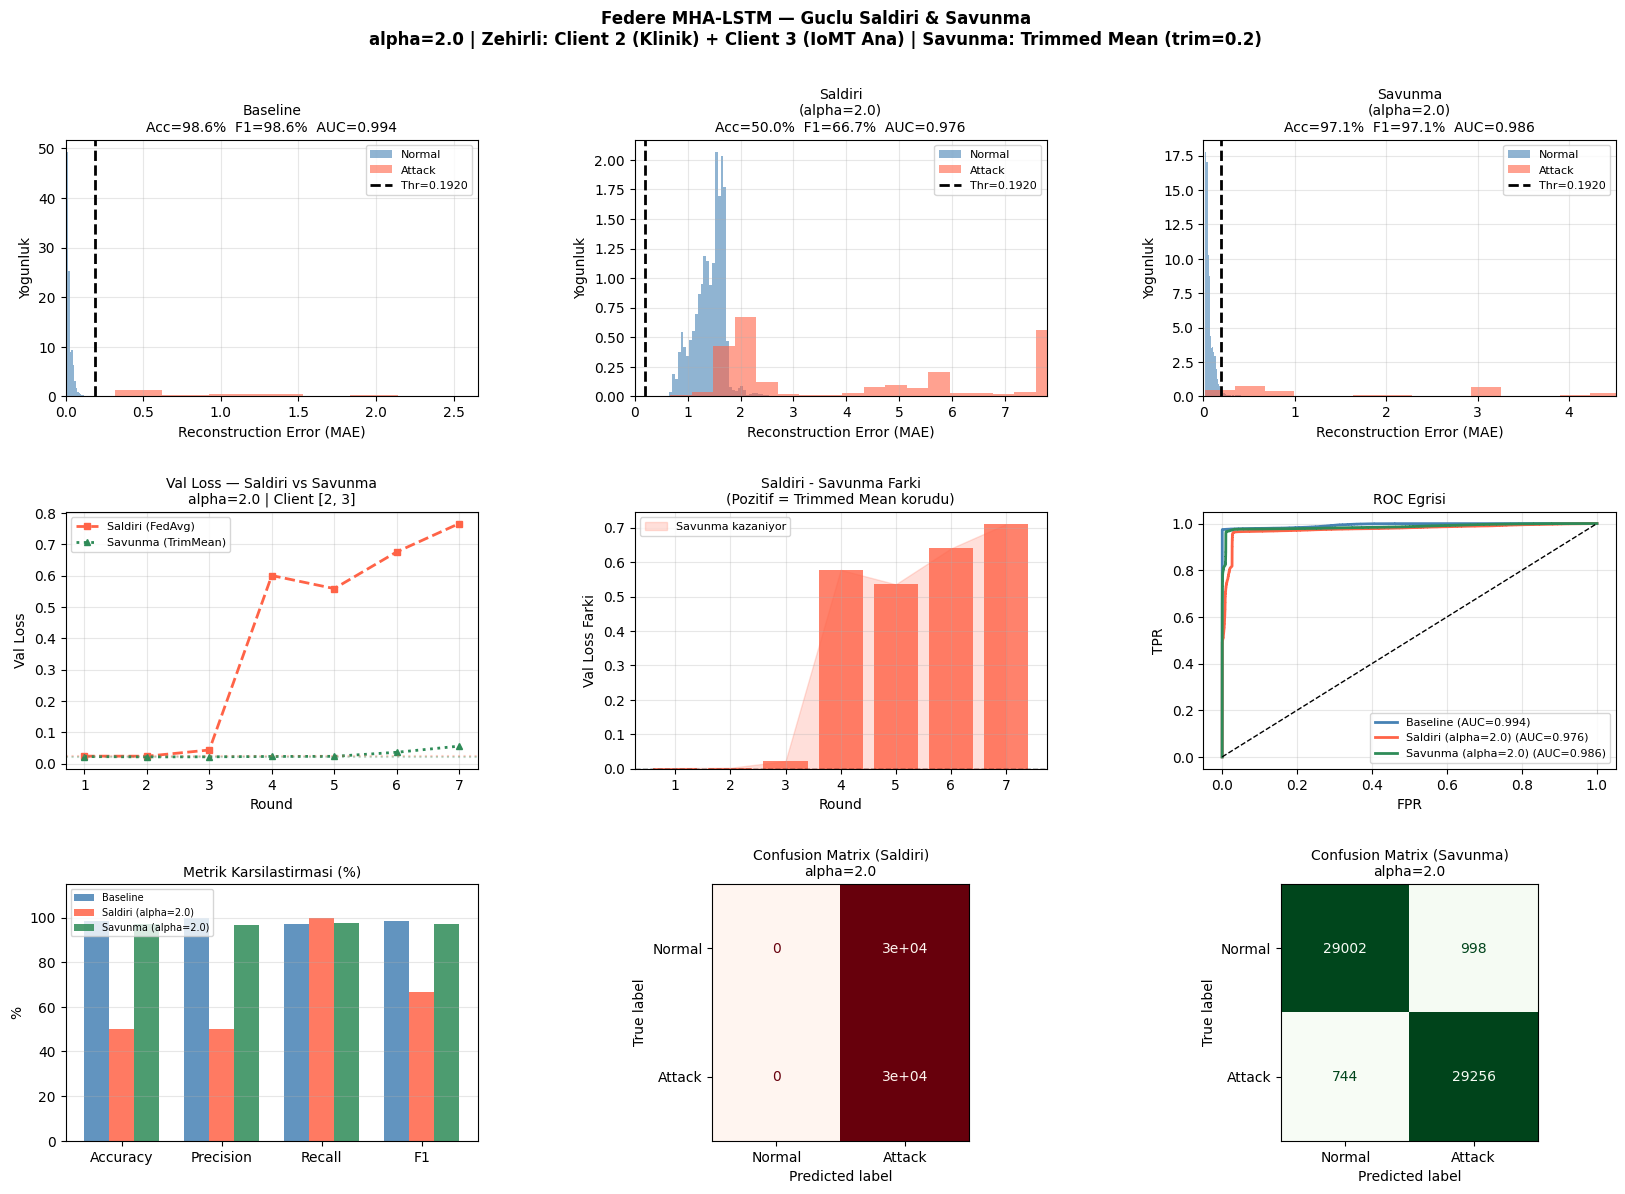

[OK] Grafik kaydedildi: /content/drive/MyDrive/mha_federe_outputs/senaryo_alpha4_clients12/guclu_saldiri_alpha2_c12.png

[OK] Tum dosyalar kaydedildi: /content/drive/MyDrive/mha_federe_outputs/senaryo_alpha4_clients12


In [ ]:
# =============================================================================
# BLOK 7 — KARSILASTIRMA VE GORSELLESTIRME
# =============================================================================

print("\n" + "=" * 72)
print("   ANOMALI TESPIT METRIKLERI — 3 SENARYO")
print(f"   (alpha={ALPHA_POISON} | Zehirli clientlar: "
      f"{[i+1 for i in COMPROMISED_CLIENT_INDICES]} = Klinik + IoMT Ana)")
print("=" * 72)
print(f"  {'Senaryo':<28} {'Acc':>7} {'Prec':>7} {'Recall':>7} {'F1':>7} {'AUC':>7}")
print("  " + "-" * 65)

results = {
    "Baseline (Temiz FedAvg)"        : metrics_baseline,
    f"Saldiri (alpha={ALPHA_POISON} FedAvg)"    : metrics_attack,
    f"Savunma (alpha={ALPHA_POISON} TrimMean)"  : metrics_defense,
}

for name, r in results.items():
    print(f"  {name:<28} "
          f"{r['accuracy']*100:>6.2f}% "
          f"{r['precision']*100:>6.2f}% "
          f"{r['recall']*100:>6.2f}% "
          f"{r['f1']*100:>6.2f}% "
          f"{r['auc']:>7.4f}")
print("=" * 72)

b, a, d = metrics_baseline, metrics_attack, metrics_defense
print(f"\n  Saldiri etkisi  (Accuracy Delta) : {(a['accuracy']-b['accuracy'])*100:+.2f}%")
print(f"  Saldiri etkisi  (F1 Delta)       : {(a['f1']-b['f1'])*100:+.2f}%")
print(f"  Savunma kurtarim (Accuracy)   : {(d['accuracy']-a['accuracy'])*100:+.2f}%")
print(f"  Savunma kurtarim (F1)         : {(d['f1']-a['f1'])*100:+.2f}%")
print(f"  Savunma vs Baseline (Acc)     : {(d['accuracy']-b['accuracy'])*100:+.2f}%")

print("\n[GRAFIK] Gorsellestirme hazirlaniyor...")

colors = ['steelblue', 'tomato', 'seagreen']
short  = ['Baseline', f'Saldiri\n(alpha={ALPHA_POISON})', f'Savunma\n(alpha={ALPHA_POISON})']

fig = plt.figure(figsize=(20, 13))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.38)

for i, (name, r) in enumerate(results.items()):
    ax = fig.add_subplot(gs[0, i])
    clip_p = np.percentile(
        np.concatenate([r['err_normal'], r['err_attack']]), 99
    )
    ax.hist(r['err_normal'], bins=60, alpha=0.6, color='steelblue',
            label='Normal', density=True)
    ax.hist(r['err_attack'], bins=60, alpha=0.6, color='tomato',
            label='Attack', density=True)
    ax.axvline(r['threshold'], color='black', ls='--', lw=2,
               label=f"Thr={r['threshold']:.4f}")
    ax.set_xlim(0, clip_p)
    ax.set_title(f"{short[i]}\n"
                 f"Acc={r['accuracy']*100:.1f}%  "
                 f"F1={r['f1']*100:.1f}%  "
                 f"AUC={r['auc']:.3f}", fontsize=10)
    ax.set_xlabel('Reconstruction Error (MAE)')
    ax.set_ylabel('Yogunluk')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

ax_loss = fig.add_subplot(gs[1, 0])
rx_a    = range(1, len(hist_attack['val_loss'])  + 1)
rx_d    = range(1, len(hist_defense['val_loss']) + 1)
ax_loss.plot(rx_a, hist_attack['val_loss'],  color='tomato',   lw=2,
             marker='s', ms=4, ls='--', label='Saldiri (FedAvg)')
ax_loss.plot(rx_d, hist_defense['val_loss'], color='seagreen', lw=2,
             marker='^', ms=4, ls=':',  label='Savunma (TrimMean)')
ax_loss.axhline(min(hist_attack['val_loss']),  color='tomato',   alpha=0.3, ls=':')
ax_loss.axhline(min(hist_defense['val_loss']), color='seagreen', alpha=0.3, ls=':')
ax_loss.set_title(f'Val Loss — Saldiri vs Savunma\n'
                  f'alpha={ALPHA_POISON} | Client {[i+1 for i in COMPROMISED_CLIENT_INDICES]}',
                  fontsize=10)
ax_loss.set_xlabel('Round')
ax_loss.set_ylabel('Val Loss')
ax_loss.legend(fontsize=8)
ax_loss.grid(True, alpha=0.3)

ax_delta = fig.add_subplot(gs[1, 1])
min_len  = min(len(hist_attack['val_loss']), len(hist_defense['val_loss']))
att_arr  = np.array(hist_attack['val_loss'][:min_len])
def_arr  = np.array(hist_defense['val_loss'][:min_len])
delta    = att_arr - def_arr
rng      = range(1, min_len + 1)
ax_delta.bar(rng, delta, color=['tomato' if d > 0 else 'steelblue' for d in delta],
             alpha=0.8)
ax_delta.axhline(0, color='black', lw=1, ls='--')
ax_delta.set_title('Saldiri - Savunma Farki\n(Pozitif = Trimmed Mean korudu)', fontsize=10)
ax_delta.set_xlabel('Round')
ax_delta.set_ylabel('Val Loss Farki')
ax_delta.grid(True, alpha=0.3)
ax_delta.fill_between(rng, delta, 0,
                       where=[d > 0 for d in delta],
                       alpha=0.2, color='tomato',
                       label='Savunma kazaniyor')
ax_delta.legend(fontsize=8)

ax_roc = fig.add_subplot(gs[1, 2])
for i, (name, r) in enumerate(results.items()):
    fpr, tpr, _ = roc_curve(r['y_true'], r['y_score'])
    ax_roc.plot(fpr, tpr, color=colors[i], lw=2,
                label=f"{short[i].replace(chr(10), ' ')} (AUC={r['auc']:.3f})")
ax_roc.plot([0, 1], [0, 1], 'k--', lw=1)
ax_roc.set_title('ROC Egrisi', fontsize=10)
ax_roc.set_xlabel('FPR')
ax_roc.set_ylabel('TPR')
ax_roc.legend(fontsize=8)
ax_roc.grid(True, alpha=0.3)

ax_bar = fig.add_subplot(gs[2, 0])
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1']
x = np.arange(len(metric_names))
for i, (name, r) in enumerate(results.items()):
    vals = [r['accuracy'], r['precision'], r['recall'], r['f1']]
    ax_bar.bar(x + i * 0.25, [v * 100 for v in vals], 0.25,
               label=short[i].replace('\n', ' '), color=colors[i], alpha=0.85)
ax_bar.set_title('Metrik Karsilastirmasi (%)', fontsize=10)
ax_bar.set_xticks(x + 0.25)
ax_bar.set_xticklabels(metric_names)
ax_bar.set_ylabel('%')
ax_bar.set_ylim(0, 115)
ax_bar.legend(fontsize=7)
ax_bar.grid(True, alpha=0.3, axis='y')

ax_cm1 = fig.add_subplot(gs[2, 1])
cm1    = confusion_matrix(metrics_attack['y_true'], metrics_attack['y_pred'])
disp1  = ConfusionMatrixDisplay(cm1, display_labels=['Normal', 'Attack'])
disp1.plot(ax=ax_cm1, colorbar=False, cmap='Reds')
ax_cm1.set_title(f'Confusion Matrix (Saldiri)\nalpha={ALPHA_POISON}', fontsize=10)

ax_cm2 = fig.add_subplot(gs[2, 2])
cm2    = confusion_matrix(metrics_defense['y_true'], metrics_defense['y_pred'])
disp2  = ConfusionMatrixDisplay(cm2, display_labels=['Normal', 'Attack'])
disp2.plot(ax=ax_cm2, colorbar=False, cmap='Greens')
ax_cm2.set_title(f'Confusion Matrix (Savunma)\nalpha={ALPHA_POISON}', fontsize=10)

plt.suptitle(
    f'Federe MHA-LSTM — Guclu Saldiri & Savunma\n'
    f'alpha={ALPHA_POISON} | Zehirli: Client 2 (Klinik) + Client 3 (IoMT Ana) | '
    f'Savunma: Trimmed Mean (trim={TRIM_RATIO})',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
fig.savefig(
    f'{RESULTS_DIR}/guclu_saldiri_alpha{int(ALPHA_POISON)}_c12.png',
    dpi=150, bbox_inches='tight', facecolor='white'
)
plt.show()
print(f"[OK] Grafik kaydedildi: {RESULTS_DIR}/guclu_saldiri_alpha{int(ALPHA_POISON)}_c12.png")

metrics_to_save = {}
for name, r in results.items():
    metrics_to_save[name] = {k: r[k] for k in
                             ['threshold', 'accuracy', 'precision',
                              'recall', 'f1', 'auc']}
joblib.dump(metrics_to_save, f'{RESULTS_DIR}/metrics_alpha4_c12.pkl')
baseline_model.save_weights(f'{RESULTS_DIR}/weights_baseline.weights.h5')
print(f"\n[OK] Tum dosyalar kaydedildi: {RESULTS_DIR}")
print("=" * 72)

In [ ]:
# =============================================================================
# BLOK 8 — OZET RAPORU
# =============================================================================

print("\n" + "=" * 72)
print("   OZET RAPORU")
print(f"   alpha={ALPHA_POISON} | Zehirli: Client 2 (Klinik) + Client 3 (IoMT Ana)")
print("=" * 72)

results = {
    "Baseline (Temiz FedAvg)"        : metrics_baseline,
    f"Saldiri (alpha={ALPHA_POISON} FedAvg)"    : metrics_attack,
    f"Savunma (alpha={ALPHA_POISON} TrimMean)"  : metrics_defense,
}

print(f"\n  SONUCLAR:")
print(f"  {'─'*55}")
print(f"  {'Senaryo':<30} {'Acc':>8} {'F1':>8} {'AUC':>8}")
print(f"  {'─'*55}")
for name, r in results.items():
    print(f"  {name:<30} "
          f"{r['accuracy']*100:>7.2f}%  "
          f"{r['f1']*100:>7.2f}%  "
          f"{r['auc']:>8.4f}")
print(f"  {'─'*55}")

b, a, d = metrics_baseline, metrics_attack, metrics_defense
print(f"\n  Saldiri etkisi  : Accuracy {(a['accuracy']-b['accuracy'])*100:+.2f}% | "
      f"F1 {(a['f1']-b['f1'])*100:+.2f}%")
print(f"  Savunma kurtarim: Accuracy {(d['accuracy']-a['accuracy'])*100:+.2f}% | "
      f"F1 {(d['f1']-a['f1'])*100:+.2f}%")

print(f"\n[BILGI] Tum modeller ve metrikler egitim asamasinda basariyla diske yazilmistir.")
print(f"Kayit Klasoru: {RESULTS_DIR}")
print("=" * 72)


   OZET RAPORU
   alpha=2.0 | Zehirli: Client 2 (Klinik) + Client 3 (IoMT Ana)

  SONUCLAR:
  ───────────────────────────────────────────────────────
  Senaryo                             Acc       F1      AUC
  ───────────────────────────────────────────────────────
  Baseline (Temiz FedAvg)          98.59%    98.57%    0.9940
  Saldiri (alpha=2.0 FedAvg)       50.00%    66.67%    0.9756
  Savunma (alpha=2.0 TrimMean)     97.10%    97.11%    0.9863
  ───────────────────────────────────────────────────────

  Saldiri etkisi  : Accuracy -48.59% | F1 -31.90%
  Savunma kurtarim: Accuracy +47.10% | F1 +30.44%

[BILGI] Tum modeller ve metrikler egitim asamasinda basariyla diske yazilmistir.
Kayit Klasoru: /content/drive/MyDrive/mha_federe_outputs/senaryo_alpha4_clients12
